<div style="box-sizing: border-box; width: 100%; max-width: 100%; background: linear-gradient(135deg, #0f172a 0%, #1e293b 60%, #0f172a 100%); padding: 28px 32px; border-radius: 16px; border: 1.5px solid rgba(56, 189, 248, 0.35); border-left: 6px solid #38bdf8; box-shadow: 0 10px 25px -5px rgba(0, 0, 0, 0.4), 0 8px 10px -6px rgba(0, 0, 0, 0.3); font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; margin: 10px 0 24px 0; overflow: hidden; color: #f8fafc;">
  
  <!-- Topic Badges -->
  <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 14px; flex-wrap: wrap;">
    <span style="background: rgba(74, 222, 128, 0.15); color: #4ade80; font-size: 0.75rem; font-weight: 600; padding: 4px 12px; border-radius: 9999px; border: 1px solid rgba(74, 222, 128, 0.35); text-transform: uppercase; letter-spacing: 0.05em;">Autumn 2026</span>
    <span style="background: rgba(251, 191, 36, 0.15); color: #fbbf24; font-size: 0.75rem; font-weight: 600; padding: 4px 12px; border-radius: 9999px; border: 1px solid rgba(251, 191, 36, 0.35); text-transform: uppercase; letter-spacing: 0.05em;">IIT KGP</span>
  </div>

  <!-- Course Title -->
  <h1 style="color: #ffffff; font-size: 1.85rem; font-weight: 700; margin: 0 0 6px 0; border: none; padding: 0; letter-spacing: -0.02em; line-height: 1.2;">
    AI31201 &bull; <a href="https://ranjan-sarkar.github.io/#rl" target="_blank" style="color: #ffffff; text-decoration: none; border-bottom: 1.5px dashed rgba(56, 189, 248, 0.5);">Reinforcement Learning (RL)</a>
  </h1>

  <!-- Tutorial Subtitle -->
  <h2 style="color: #93c5fd; font-size: 1.45rem; font-weight: 600; margin: 0 0 14px 0; border: none; padding: 0; letter-spacing: -0.01em;">
    Tutorial 4: Value Iteration &bull; Gambler's Problem
  </h2>

  <!-- Instructor / TA Info Row -->
  <div style="display: flex; gap: 16px; margin-bottom: 16px; flex-wrap: wrap; font-size: 0.95rem; color: #cbd5e1; gap: 4px">
    <div>
      <span style="color: #94a3b8; font-weight: 600;">Instructor:</span>
      <a href="https://prabhatkmishra.github.io/people.html" target="_blank" style="color: #f1f5f9; font-weight: 600; text-decoration: none; margin-left: 4px;">Dr. Prabhat Kumar Mishra</a>
    </div>
    <div>
      <span style="color: #94a3b8; font-weight: 600;">TAs:</span>
      <a href="https://ranjan-sarkar.github.io" target="_blank" style="color: #f1f5f9; font-weight: 600; text-decoration: none; margin-left: 4px;">Ranjan Sarkar</a>
    </div>
  </div>

  <!-- Reference & Quick Links Footer -->
  <div style="padding-top: 14px; border-top: 1px solid rgba(255, 255, 255, 0.1); display: flex; align-items: center; gap: 10px; flex-wrap: wrap;">
    <span style="color: #64748b; font-size: 0.8rem; font-weight: 700; text-transform: uppercase; letter-spacing: 0.05em;">References:</span>
    <a href="http://incompleteideas.net/book/the-book-2nd.html" target="_blank" style="color: #c084fc; font-size: 0.85rem; font-weight: 600; text-decoration: none; background: rgba(168, 85, 247, 0.1); padding: 5px 12px; border-radius: 6px; border: 1px solid rgba(168, 85, 247, 0.25); display: inline-flex; align-items: center; gap: 4px;">
      📖 Sutton &amp; Barto (Section 4.4 &amp; Example 4.3) ↗
    </a>
    <a href="https://github.com/ShangtongZhang/reinforcement-learning-an-introduction/tree/master" target="_blank" style="color: #38bdf8; font-size: 0.85rem; font-weight: 600; text-decoration: none; background: rgba(56, 189, 248, 0.1); padding: 5px 12px; border-radius: 6px; border: 1px solid rgba(56, 189, 248, 0.25); display: inline-flex; align-items: center; gap: 4px;">
      💻 GitHub Repository ↗
    </a>
  </div>

</div>

# 1. **Problem Formulation: Sutton & Barto Example 4.3 (Gambler's Problem)**

A gambler has the opportunity to make bets on the outcomes of a sequence of coin flips:
- If the coin lands **heads**, the gambler **wins** as many dollars as staked on that flip.
- If the coin lands **tails**, the gambler **loses** the stake.
- The game terminates when the gambler either reaches the goal of **$100**, or loses all money (**$0** capital).
- On each flip, the gambler decides what integer stake $a$ to wager, where $a \in \{1, 2, \dots, \min(s, 100 - s)\}$ and $s$ is the current capital.

---

### **Markov Decision Process (MDP) Formulation:**
- **State Space ($\mathcal{S}$):** Current capital in integer dollars:
  $$\mathcal{S} = \{1, 2, \dots, 99\}$$
- **Terminal States ($\mathcal{S}^+$):**
  $$\mathcal{S}^+ = \{0, 100\} \quad \text{with boundary conditions } V(0) = 0 \text{ (ruin) and } V(100) = 1 \text{ (goal)}$$
- **Action Space ($\mathcal{A}(s)$):** Permissible stakes given current capital $s$:
  $$\mathcal{A}(s) = \{1, 2, \dots, \min(s, 100 - s)\}$$
  since we have $$a \le s, ~ a \le 100-s.$$
- **Transition Dynamics:**
  For a stake $a$ from capital $s$:
  $$p(s + a \mid s, a) = p_h \quad \text{(Heads: gambler wins stake } a\text{)}$$
  $$p(s - a \mid s, a) = 1 - p_h \quad \text{(Tails: gambler loses stake } a\text{)}$$
- **Reward & Value Interpretation:**
  In this episodic undiscounted task ($\gamma = 1.0$), the reward is $+1$ upon reaching the goal of $100$ and $0$ on all other transitions.

  Equivalently, with boundary values are $$V(0) = 0 \text{ and } V(100) = 1,$$ and the state value $V(s)$ represents the **exact probability of winning the game** starting from capital $s$.
- **Probability of Heads:** $p_h = 0.4$ (the coin is biased against the gambler).

---

### **Bellman Optimality Equation:**
$$V^*(s) = \max_{a \in \mathcal{A}(s)} \left[ p_h V^*(s + a) + (1 - p_h) V^*(s - a) \right], \quad \forall s \in \{1, \dots, 99\}$$

# 2. **Environment: `GamblersProblem`**

Importing libraries and configuring styling parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
import matplotlib.patches as patches
from IPython.display import HTML

from IPython.display import HTML
from IPython import get_ipython
ipython = get_ipython()
# for better resolution of plots in Notebook
ipython.run_line_magic('config', "InlineBackend.figure_format = 'retina'")

# Configure Matplotlib styling: fonts, high-DPI rendering
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'serif']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12

Setup the `GamblersProblem` Environment Class

In [2]:
class GamblersProblem:
    '''
    Gambler's Problem Environment (Sutton & Barto Example 4.3).
    - States: Capital s in {1, 2, ..., goal-1}.
    - Terminal States: 0 (ruin, V=0) and goal (success, V=1).
    - Actions: Integer stake a in {1, ..., min(s, goal - s)}.
    - Coin Probability: p_h is probability of winning a heads flip.
    - Discount factor gamma = 1.0 (undiscounted episodic task).
    '''
    def __init__(self, goal=100, p_h=0.4, gamma=1.0):
        self.goal = goal
        self.p_h = p_h
        self.gamma = gamma
        self.non_terminal_states = list(range(1, self.goal))
        self.all_states = list(range(self.goal + 1))
        
    def get_actions(self, s):
        '''Valid stakes: gambler cannot stake more than capital s or distance to goal.'''
        if self.is_terminal(s):
            return []
        max_stake = min(s, self.goal - s)
        return list(range(1, max_stake + 1))
        
    def is_terminal(self, s):
        '''Check if capital s reached ruin (0) or goal (100).'''
        return s == 0 or s == self.goal
        
    def get_transitions(self, s, a):
        '''
        Returns outcome states and probabilities for stake a at state s:
        List of tuples: (next_state, transition_probability)
        '''
        return [
            (s + a, self.p_h),           # Heads: win stake a
            (s - a, 1.0 - self.p_h)      # Tails: lose stake a
        ]

# Initialize the environment with p_h = 0.4
env = GamblersProblem(goal=100, p_h=0.4)
print(f"Initialized Gambler's Problem: Goal = ${env.goal}, p_h = {env.p_h}, States = {len(env.all_states)}")

Initialized Gambler's Problem: Goal = $100, p_h = 0.4, States = 101


# 3. **Value Iteration Algorithm**

$$
\begin{aligned}
&\boxed{\textbf{Value Iteration, for estimating } \pi \approx \pi_*} \\[8pt]

&\text{Thresold: } \theta > 0 \text{ (a small positive number determining accuracy of estimation)} \\[6pt]

&\text{Initialize } V(s), \text{ for all } s \in \mathcal{S}^+, \text{ arbitrarily except that } V(\text{terminal}) = 0 \\[10pt]

&\text{Loop:} \\
&\qquad \Delta \leftarrow 0 \\
&\qquad \text{Loop for each } s \in \mathcal{S}: \\
&\qquad\qquad v \leftarrow V(s) \\
&\qquad\qquad V(s) \leftarrow \max_a \sum_{s', r} p(s', r \mid s, a) \left[ r + \gamma V(s') \right] \\
&\qquad\qquad \Delta \leftarrow \max\left(\Delta, |v - V(s)|\right) \\
&\text{until } \Delta < \theta \\[10pt]

&\text{Output a deterministic policy, } \pi \approx \pi_*, \text{ such that} \\
&\qquad \pi(s) = \arg\max_a \sum_{s', r} p(s', r \mid s, a) \left[ r + \gamma V(s') \right]
\end{aligned}
$$

> **Application to Gambler's Problem:**
> In the Gambler's Problem, the 1-step Bellman expectation simplifies directly to:
> $$\sum_{s', r} p(s', r \mid s, a) \left[ r + \gamma V(s') \right] = p_h V(s + a) + (1 - p_h) V(s - a)$$
> with boundary conditions $V(0) = 0$ and $V(100) = 1$.

In [3]:
def value_iteration(env, theta=1e-9, tol=1e-5):
    '''
    Value Iteration algorithm for the Gambler's Problem.
    
    Parameters:
        env: GamblersProblem environment instance
        theta: Convergence threshold for Bellman optimality backup delta
        tol: Numerical tolerance for detecting ties in action-values Q(s, a)
        
    Returns:
        V: Converged optimal state-value function (size goal + 1)
        policy: Optimal deterministic stake policy pi*(s)
        sweeps_history: List of (sweep_num, V_snapshot) recorded during iteration
        all_optimal_actions: Dictionary mapping each state s to all actions achieving max Q*(s, a)
    '''
    # Initialize value function: V(0) = 0.0, V(goal) = 1.0, non-terminal states = 0.0
    V = np.zeros(env.goal + 1)
    V[env.goal] = 1.0  # Terminal state at goal has value 1.0
    
    sweeps_history = []
    sweep = 0
    
    while True:
        delta = 0.0
        new_V = V.copy()
        
        # Sweep over non-terminal states
        for s in env.non_terminal_states:
            actions = env.get_actions(s)
            
            # Compute Q(s, a) = p_h * V(s + a) + (1 - p_h) * V(s - a)
            q_values = [env.p_h * V[s + a] + (1.0 - env.p_h) * V[s - a] for a in actions]
            best_value = max(q_values)
            
            delta = max(delta, abs(best_value - V[s]))
            new_V[s] = best_value
            
        V = new_V
        sweep += 1
        sweeps_history.append((sweep, V.copy()))
        
        # Convergence check
        if delta < theta:
            break
            
    # Extract greedy policy with respect to converged V*
    policy = np.zeros(env.goal + 1, dtype=int)
    all_optimal_actions = {}
    
    for s in env.non_terminal_states:
        actions = env.get_actions(s)
        q_values = [env.p_h * V[s + a] + (1.0 - env.p_h) * V[s - a] for a in actions]
        max_q = max(q_values)
        
        # Identify all actions that achieve optimal value within numerical tolerance
        optimal_acts = [actions[i] for i, q in enumerate(q_values) if np.isclose(q, max_q, atol=tol)]
        all_optimal_actions[s] = optimal_acts
        
        # Sutton & Barto Figure 4.3 canonical policy: pick first maximizer (smallest stake)
        # Rounding avoids minute floating-point numerical precision artifacts
        rounded_q = np.round(q_values, decimals=5)
        policy[s] = actions[np.argmax(rounded_q)]
        
    return V, policy, sweeps_history, all_optimal_actions

# Execute Value Iteration
optimal_V, optimal_policy, sweeps_history, all_optimal_actions = value_iteration(env, theta=1e-9)

print(f"Value Iteration converged in {len(sweeps_history)} sweeps.")
print(f"Optimal Value at Capital $25: {optimal_V[25]:.4f}")
print(f"Optimal Value at Capital $50: {optimal_V[50]:.4f}")
print(f"Optimal Value at Capital $75: {optimal_V[75]:.4f}")
print(f"Optimal Stakes at Capital $25: {optimal_policy[25]}, $50: {optimal_policy[50]}, $75: {optimal_policy[75]}")

Value Iteration converged in 31 sweeps.
Optimal Value at Capital $25: 0.1600
Optimal Value at Capital $50: 0.4000
Optimal Value at Capital $75: 0.6400
Optimal Stakes at Capital $25: 25, $50: 50, $75: 25


# 4. **Visualization | Sutton & Barto Figure 4.3**

Figure 4.3 from *Sutton & Barto (Reinforcement Learning: An Introduction, 2nd Edition, page 84)* illustrates two key RL concepts:

1. **Value Function Sweeps (Top Panel):**
   - In early sweeps ($k=1, 2, 3$), non-terminal values remain zero except at states from which the goal ($100$) can be reached within $k$ flips.
   - Values propagate backwards from the absorbing goal $s=100$, forming distinctive step plateaus at binary powers ($50, 75, 25, \dots$).
   - As $k \to \infty$, $V(s)$ smoothly approaches the optimal probability of winning the game from capital $s$.
2. **Optimal Policy Structure (Bottom Panel):**
   - The optimal policy exhibits a famous **sawtooth / pyramidal structure** with major peaks at $s=25, 50, 75$, and sub-peaks at $12, 37, 62, 87$.
   - **Why does the policy stake 50 at 50?** Because the coin flip is unfavorable ($p_h = 0.4 < 0.5$). In any unfavorable game, the law of large numbers works *against* the gambler with every additional flip. Thus, the optimal approach is **bold play**: make the fewest possible bets to reach the goal! At $s=50$, staking $50$ gives a direct $40\%$ chance of reaching $100$ in just one flip. Betting smaller stakes would require winning multiple coin tosses, where $(0.4)^n$ diminishes exponentially.
   - **Multiplicity of Optimal Policies:** There are numerous ties in $Q^*(s, a)$. For example, at capital $s=50$, staking $50$ or staking $25$ can lead to equivalent expected values if followed by optimal play. Picking the first maximizer (smallest stake) yields the classic plot published in the book.

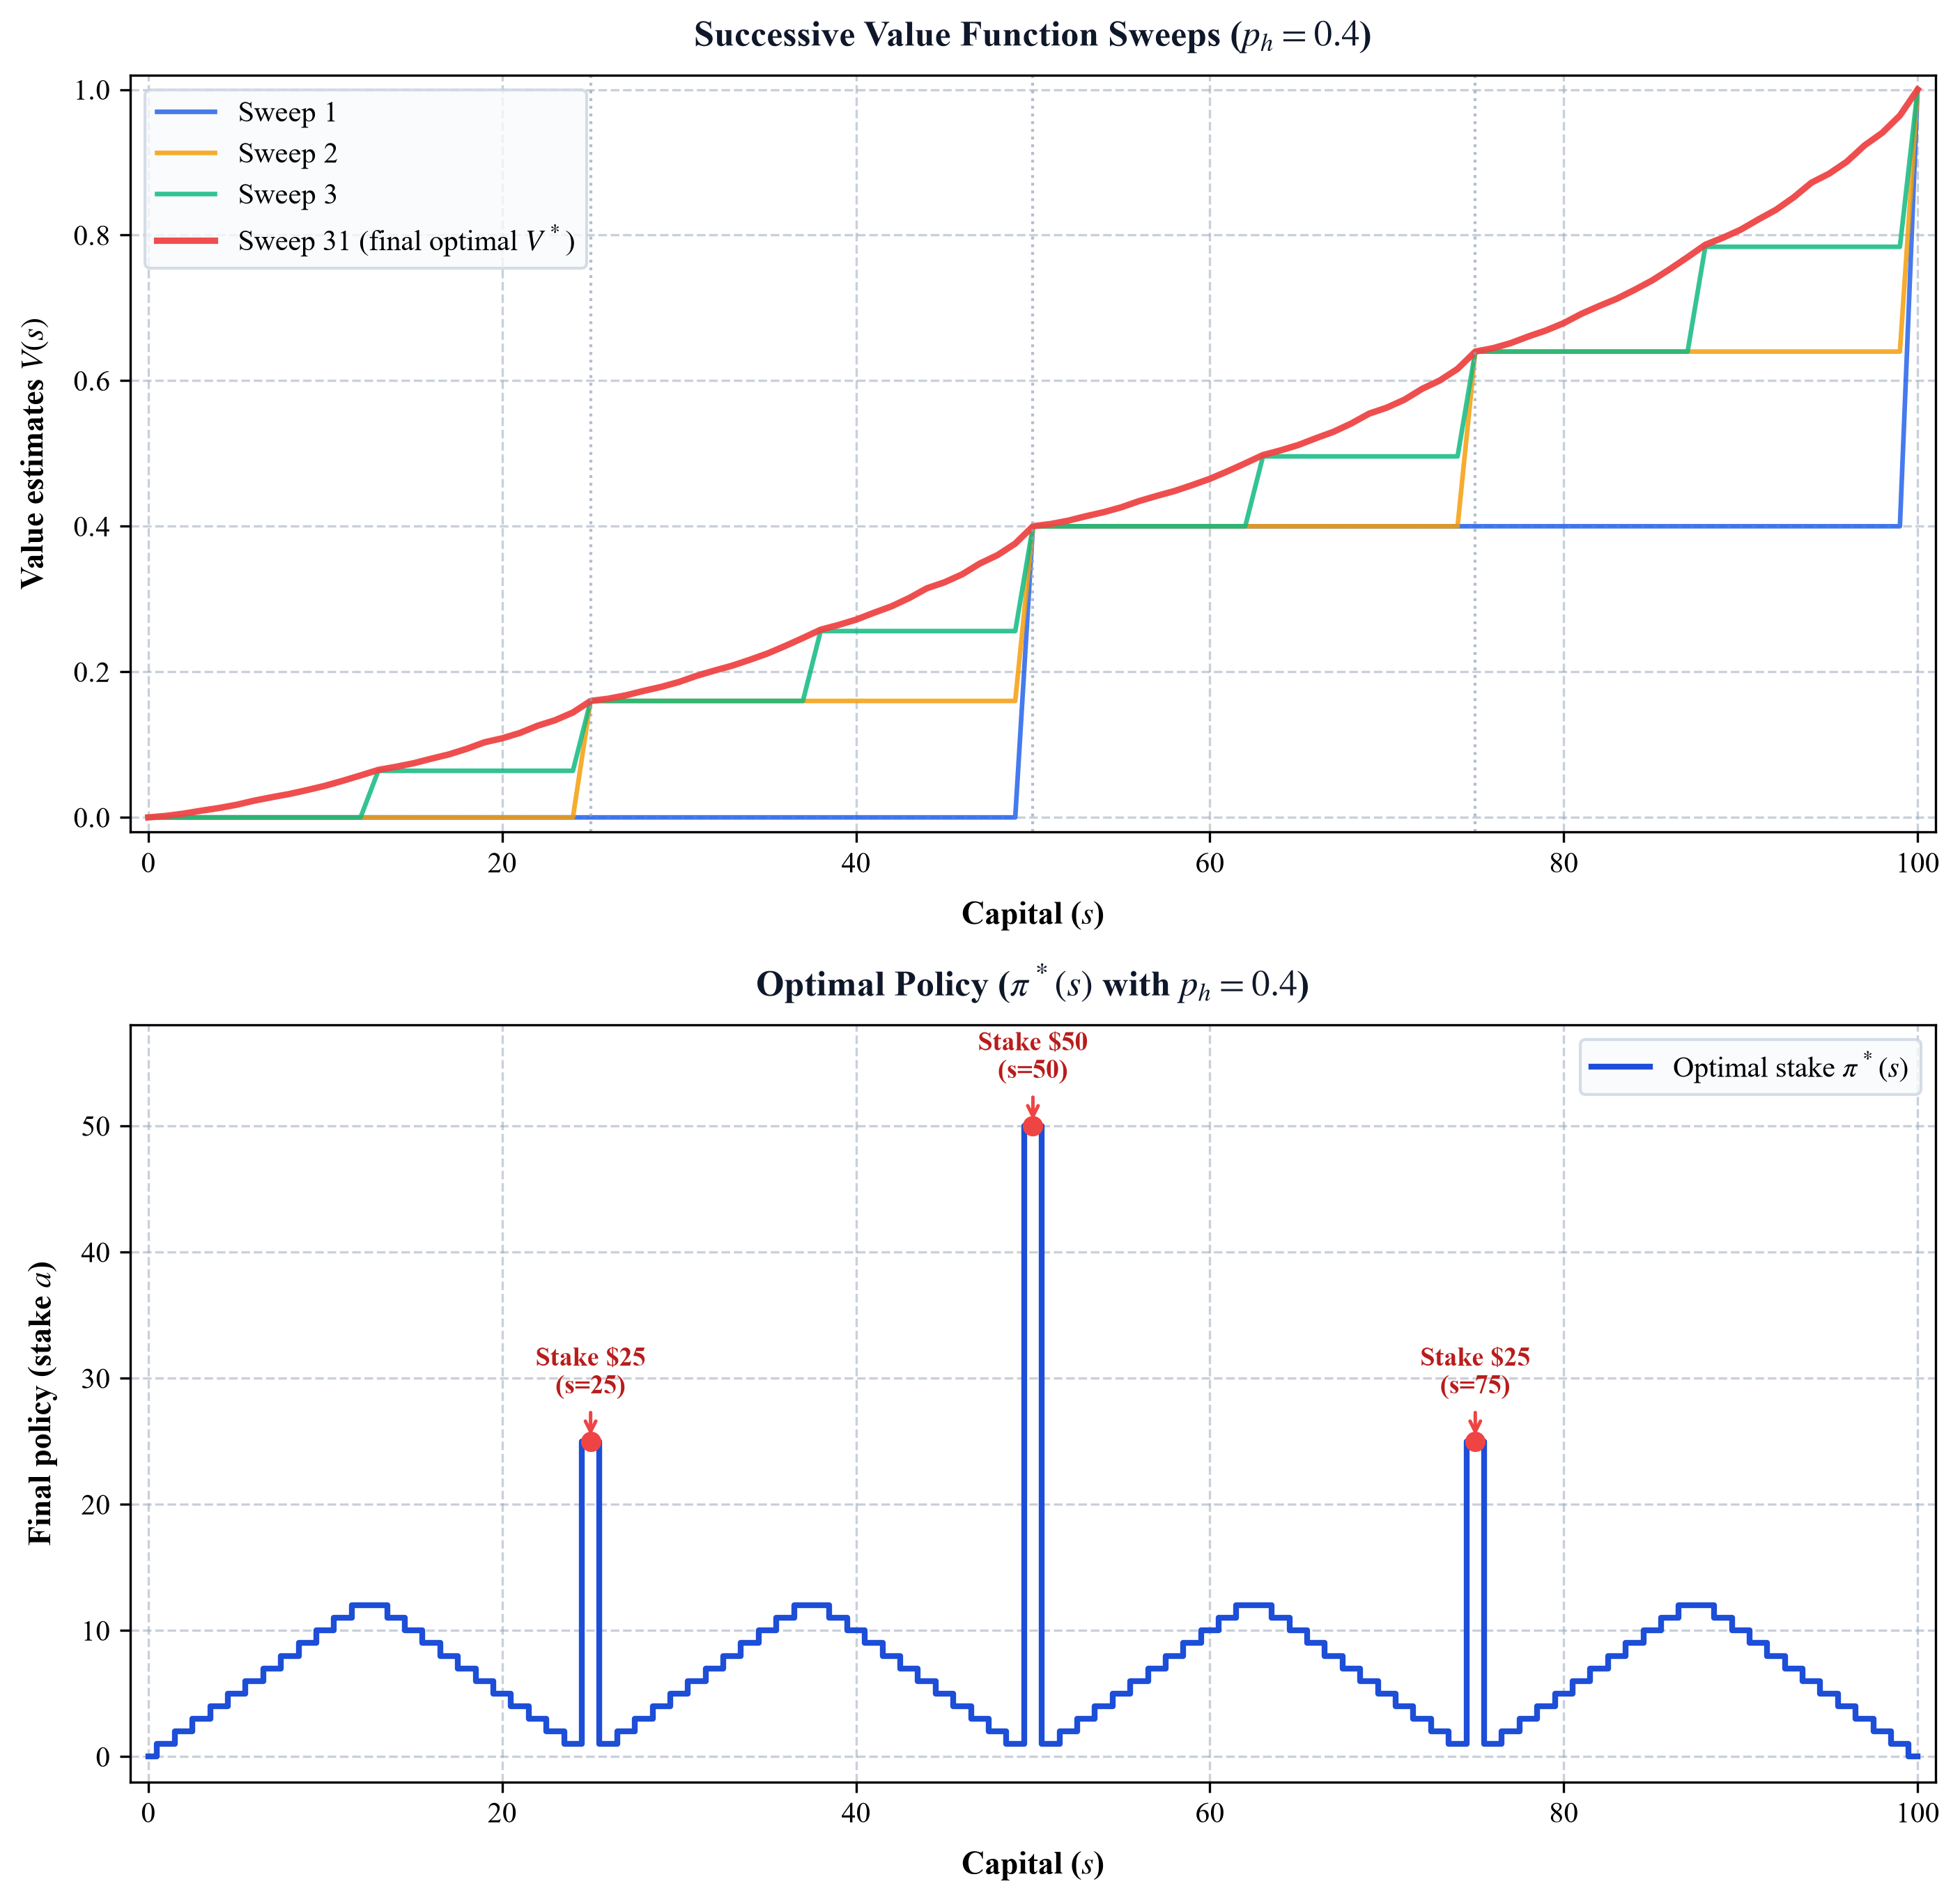

In [4]:
# Create publication-quality dual-panel plot matching Figure 4.3
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 9.2), dpi=150, facecolor='#ffffff')

# -----------------------------------------------------------------
# Top Subplot: Value Function Estimates V_k(s) across Sweeps
# -----------------------------------------------------------------
colors = {1: '#2563eb', 2: '#f59e0b', 3: '#10b981', 'final': '#ef4444'}
selected_sweeps = [1, 2, 3, len(sweeps_history)]

for sw in selected_sweeps:
    sw_num, v_snapshot = sweeps_history[sw - 1]
    if sw_num == len(sweeps_history):
        label = f'Sweep {sw_num} (final optimal $V^*$)'
        col = colors['final']
        lw = 2.2
        alpha = 0.95
    else:
        label = f'Sweep {sw_num}'
        col = colors[sw_num]
        lw = 1.6
        alpha = 0.85
        
    ax1.plot(range(env.goal + 1), v_snapshot, label=label, color=col, linewidth=lw, alpha=alpha)

ax1.set_xlim(-1, 101)
ax1.set_ylim(-0.02, 1.02)
ax1.set_xlabel('Capital ($s$)', fontsize=11, fontweight='bold', labelpad=8)
ax1.set_ylabel('Value estimates $V(s)$', fontsize=11, fontweight='bold', labelpad=8)
ax1.set_title(r"Successive Value Function Sweeps ($p_h = 0.4$)", 
              fontsize=12.5, fontweight='bold', pad=10, color='#0f172a')
ax1.legend(loc='upper left', frameon=True, facecolor='#f8fafc', edgecolor='#cbd5e1', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.5, color='#94a3b8')

# Annotate milestone thresholds
for pt in [25, 50, 75]:
    ax1.axvline(x=pt, color='#94a3b8', linestyle=':', linewidth=1.0, alpha=0.7)

# -----------------------------------------------------------------
# Bottom Subplot: Optimal Policy (Stake vs Capital)
# -----------------------------------------------------------------
ax2.step(range(env.goal + 1), optimal_policy, where='mid', color='#1d4ed8', linewidth=2.0, label=r'Optimal stake $\pi^*(s)$')

ax2.set_xlim(-1, 101)
ax2.set_ylim(-2, 58)
ax2.set_xlabel('Capital ($s$)', fontsize=11, fontweight='bold', labelpad=8)
ax2.set_ylabel(r'Final policy (stake $a$)', fontsize=11, fontweight='bold', labelpad=8)
ax2.set_title(r"Optimal Policy ($\pi^*(s)$ with $p_h = 0.4$)", 
              fontsize=12.5, fontweight='bold', pad=10, color='#0f172a')
ax2.grid(True, linestyle='--', alpha=0.5, color='#94a3b8')

# Highlight prominent peaks
peaks = [(25, 25), (50, 50), (75, 25)]
for cap, stake in peaks:
    ax2.plot(cap, stake, 'o', color='#ef4444', markersize=6)
    ax2.annotate(f'Stake ${stake}\n(s={cap})', xy=(cap, stake), xytext=(cap, stake + 3.8),
                 ha='center', fontsize=9, fontweight='bold', color='#b91c1c',
                 arrowprops=dict(arrowstyle='->', color='#ef4444', lw=1.2))

ax2.legend(loc='upper right', frameon=True, facecolor='#f8fafc', edgecolor='#cbd5e1', fontsize=10)

plt.tight_layout()
plt.savefig('fig_4_3_gambler.png', dpi=300)
plt.show()

# 5. **Step-Wise Interactive Animation**

Observe the dynamic convergence of the value function $V_k(s)$ alongside the corresponding greedy policy $\pi_k(s)$ across each sweep of Value Iteration.

In [5]:
def create_gambler_animation(env, sweeps_history, dpi=150):
    '''
    Generates an animation of the Value Iteration sweeps:
    - Left Panel: Evolution of the State-Value function V_k(s)
    - Right Panel: Evolution of the corresponding Greedy Policy pi_k(s)
    '''
    total_sweeps = len(sweeps_history)
    frame_indices = [i for i in range(total_sweeps) if i < 10 or i % 2 == 0 or i == total_sweeps - 1]
    
    fig, (ax_v, ax_p) = plt.subplots(1, 2, figsize=(12.0, 5.0), dpi=dpi, facecolor='#ffffff')
    suptitle = fig.suptitle(r"Value Iteration • Gambler's Problem | Sweep $k = 1$", 
                            fontsize=13.5, fontweight='bold', color="#0f172a", y=0.98)
    fig.subplots_adjust(top=0.84, bottom=0.14, left=0.07, right=0.95, wspace=0.25)
    
    # Left Subplot: V(s)
    line_v, = ax_v.plot([], [], color='#2563eb', lw=2.2, label=r'$V_k(s)$')
    ax_v.set_xlim(0, env.goal)
    ax_v.set_ylim(-0.05, 1.05)
    ax_v.set_xlabel('Capital ($s$)', fontsize=10.5, fontweight='bold')
    ax_v.set_ylabel('Value Estimate $V(s)$', fontsize=10.5, fontweight='bold')
    ax_v.set_title(r"Value Function Evolution $V_k(s)$", fontsize=11.5, fontweight='bold', color='#0f172a')
    ax_v.grid(True, linestyle='--', alpha=0.4)
    ax_v.legend(loc='upper left', frameon=True, facecolor='#f8fafc', edgecolor='#cbd5e1')
    
    # Right Subplot: Policy pi(s)
    step_p, = ax_p.step([], [], where='mid', color='#059669', lw=2.0, label=r'Greedy Stake $\pi_k(s)$')
    ax_p.set_xlim(0, env.goal)
    ax_p.set_ylim(-2, 55)
    ax_p.set_xlabel('Capital ($s$)', fontsize=10.5, fontweight='bold')
    ax_p.set_ylabel('Stake ($a$)', fontsize=10.5, fontweight='bold')
    ax_p.set_title(r"Greedy Policy $\pi_k(s)$", fontsize=11.5, fontweight='bold', color='#0f172a')
    ax_p.grid(True, linestyle='--', alpha=0.4)
    ax_p.legend(loc='upper right', frameon=True, facecolor='#f8fafc', edgecolor='#cbd5e1')
    
    def animate_frame(idx):
        sw_idx = frame_indices[idx]
        sweep_num, V_curr = sweeps_history[sw_idx]
        
        # Compute greedy policy for current V_curr
        pol_curr = np.zeros(env.goal + 1, dtype=int)
        for s in env.non_terminal_states:
            acts = env.get_actions(s)
            q_vals = [env.p_h * V_curr[s + a] + (1.0 - env.p_h) * V_curr[s - a] for a in acts]
            rounded_q = np.round(q_vals, decimals=5)
            pol_curr[s] = acts[np.argmax(rounded_q)]
            
        line_v.set_data(range(env.goal + 1), V_curr)
        step_p.set_data(range(env.goal + 1), pol_curr)
        
        is_converged = (sweep_num == total_sweeps)
        status = "(Converged Optimal)" if is_converged else ""
        suptitle.set_text(f"Value Iteration • Gambler's Problem ($p_h = {env.p_h}$) | Sweep $k = {sweep_num}$ {status}")
        return [line_v, step_p, suptitle]
        
    anim = animation.FuncAnimation(fig, animate_frame, frames=len(frame_indices), interval=350, blit=False)
    plt.close(fig)
    return anim

# Generate interactive animation object
anim_gambler = create_gambler_animation(env, sweeps_history, dpi=150)

# Save animation as HD GIF
writer = animation.PillowWriter(fps=3)
anim_gambler.save('animation.gif', writer=writer, dpi=200)
print("Saved animation to animation.gif")

# Display interactive animation inside the notebook
HTML(anim_gambler.to_jshtml())

Saved animation to animation.gif


# 6. **Comparative Analysis: Varying Head Probability ($p_h$)**

*(Sutton & Barto Exercise 4.9)* What happens when the coin is even more biased against the gambler ($p_h = 0.25$), or when the coin flip is favorable ($p_h = 0.55$)?

- **When $p_h < 0.5$ (e.g. $p_h = 0.25$ or $0.40$):** 
  The game is unfavorable. The gambler maximizes success by **bold play**: minimizing the expected number of flips so the adverse drift does not erode capital.
- **When $p_h > 0.5$ (e.g. $p_h = 0.55$):** 
  The odds are in the gambler's favor! Here, the law of large numbers works *for* the gambler. The optimal policy becomes **timid play**: stake the minimal amount ($a = 1$) to steadily accumulate capital toward $100$ while minimizing the probability of ruin.

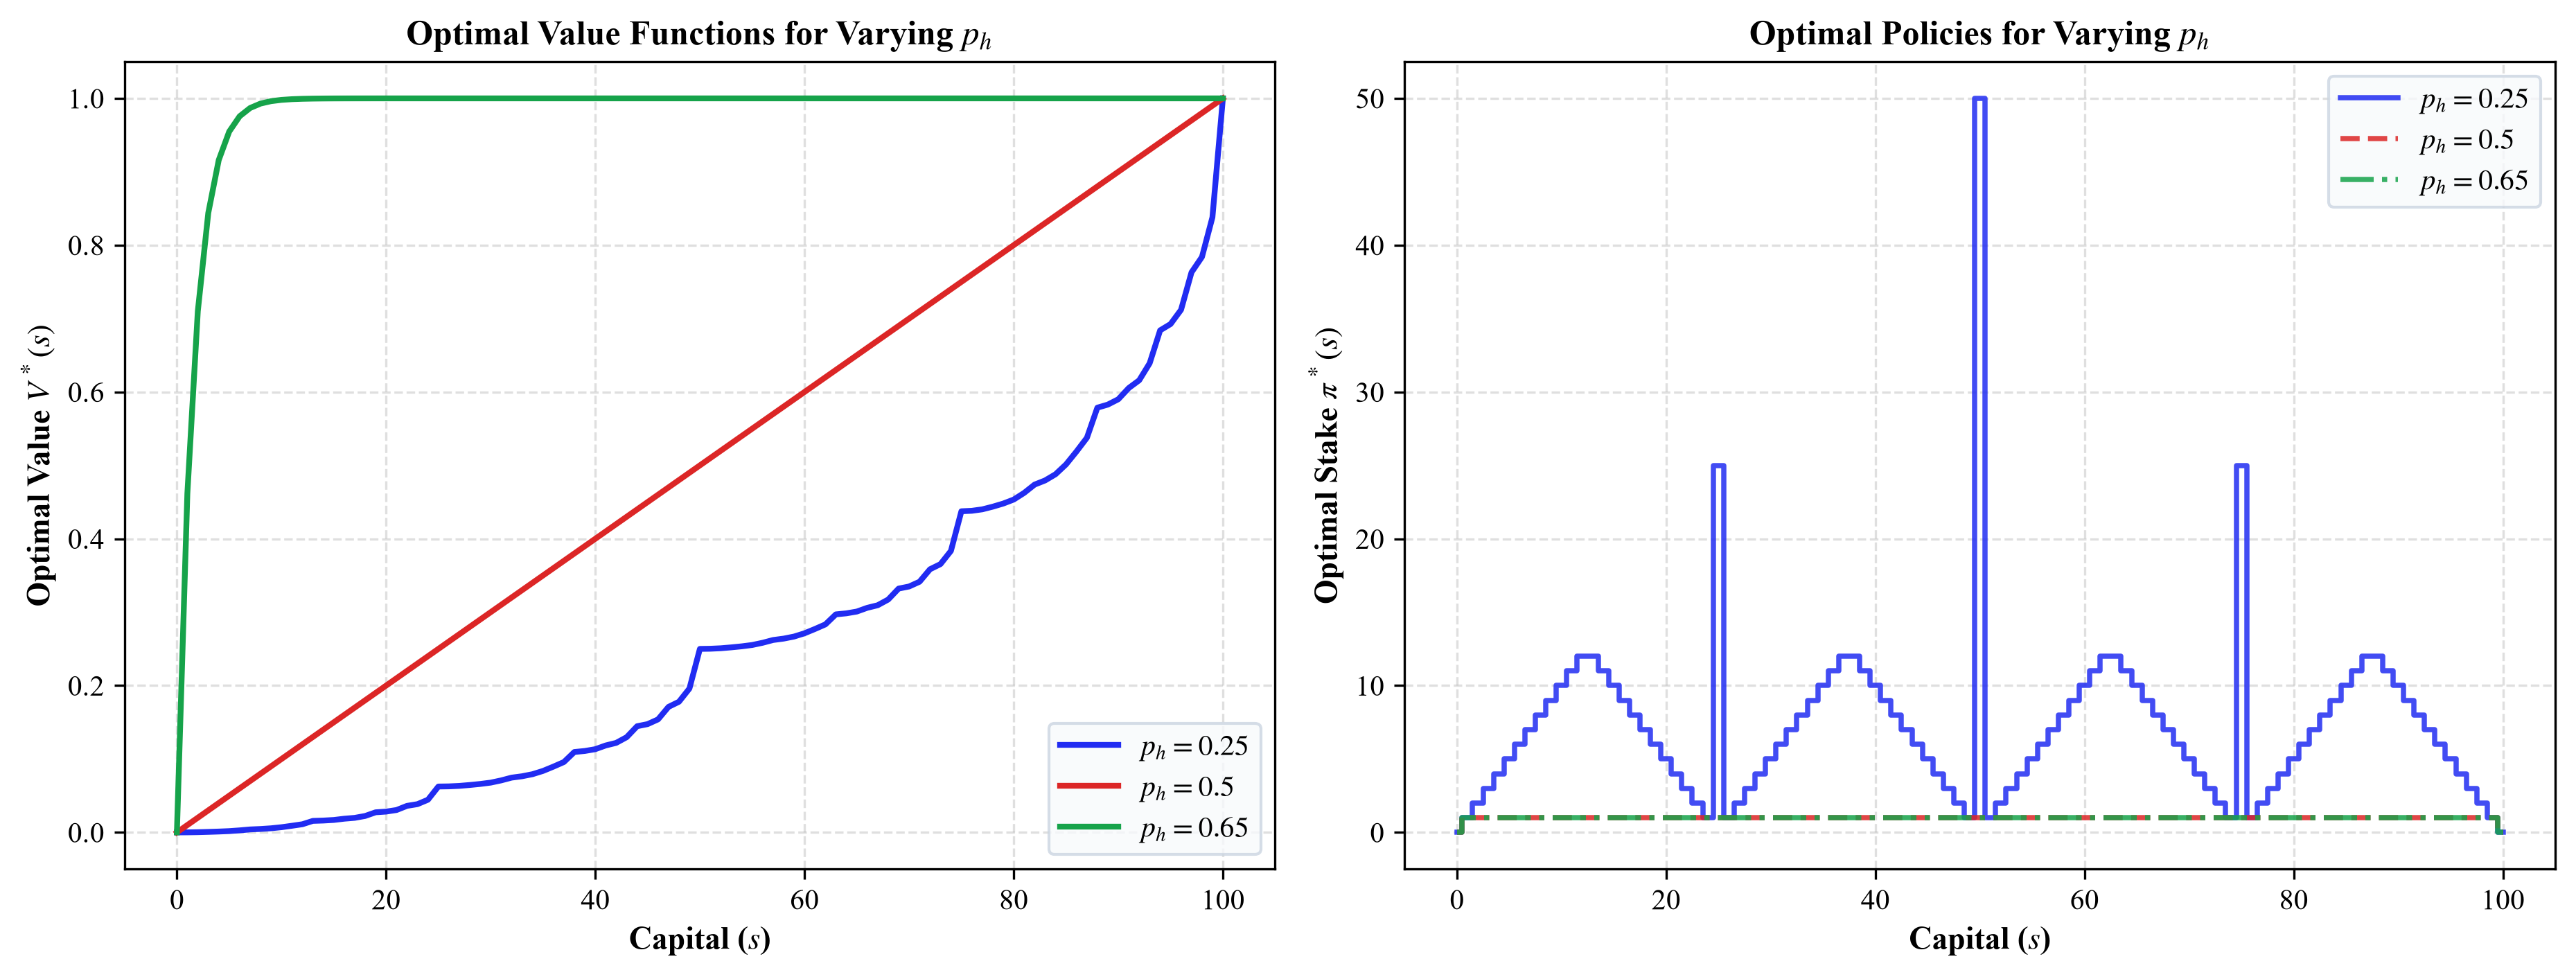

In [7]:
# Run Value Iteration for different coin probabilities
p_h_values = [0.25, 0.50, 0.65]
results = {}

for p in p_h_values:
    cur_env = GamblersProblem(goal=100, p_h=p)
    V_res, pi_res, _, _ = value_iteration(cur_env, theta=1e-9)
    results[p] = (V_res, pi_res)

fig, (ax_v, ax_p) = plt.subplots(1, 2, figsize=(12.5, 4.8), dpi=150, facecolor='#ffffff')
color_map = dict(zip(p_h_values, ["#212cf2", '#dc2626', '#16a34a']))
line_styles = dict(zip(p_h_values, ['-', '--', '-.']))

for p in p_h_values:
    V_p, pi_p = results[p]
    ax_v.plot(range(101), V_p, label=f'$p_h = {p}$', color=color_map[p], lw=2.0)
    ax_p.step(range(101), pi_p, where='mid', label=f'$p_h = {p}$', color=color_map[p], lw=1.8, alpha=0.85, linestyle=line_styles[p])

ax_v.set_xlabel('Capital ($s$)', fontsize=11, fontweight='bold')
ax_v.set_ylabel(r'Optimal Value $V^*(s)$', fontsize=11, fontweight='bold')
ax_v.set_title(r'Optimal Value Functions for Varying $p_h$', fontsize=12, fontweight='bold')
ax_v.legend(frameon=True, facecolor='#f8fafc', edgecolor='#cbd5e1')
ax_v.grid(True, linestyle='--', alpha=0.4)

ax_p.set_xlabel('Capital ($s$)', fontsize=11, fontweight='bold')
ax_p.set_ylabel(r'Optimal Stake $\pi^*(s)$', fontsize=11, fontweight='bold')
ax_p.set_title(r'Optimal Policies for Varying $p_h$', fontsize=12, fontweight='bold')
ax_p.legend(frameon=True, facecolor='#f8fafc', edgecolor='#cbd5e1')
ax_p.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

---
<div style="text-align: center; color: #94a3b8; font-size: 0.85rem; margin-top: 16px;">
  Sep 11, 2026 - AI31201 Reinforcement Learning &bull; Autumn 2026 &bull; IIT Kharagpur
</div>